In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [8]:
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2,
    random_state=42
)

In [9]:
df = pd.DataFrame(X, columns=["Feature_1","Feature_2"])

df["Target"] = y

df.head()

,Feature_1,Feature_2,Target
0,2.008455,-2.047010,0
1,1.326021,1.502541,1
2,2.024205,-2.797143,0
3,1.121880,0.059371,0
4,1.039100,1.382369,1


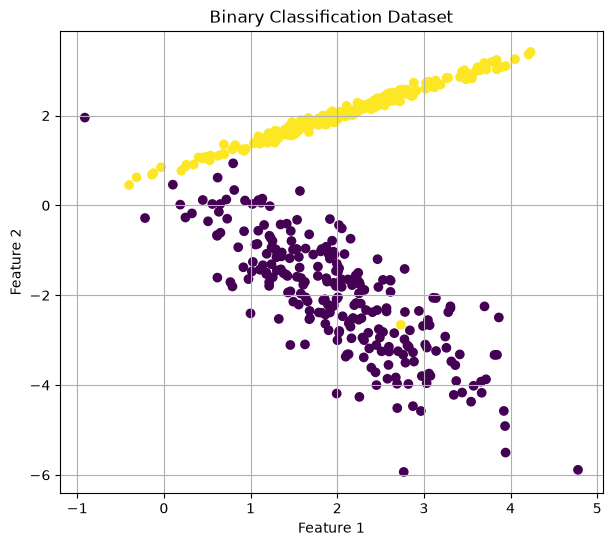

In [10]:
plt.figure(figsize=(7,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y
)

plt.xlabel("Feature 1")

plt.ylabel("Feature 2")

plt.title("Binary Classification Dataset")

plt.grid()

plt.show()

In [11]:
X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [13]:
def sigmoid(z):

    return 1/(1+np.exp(-z))

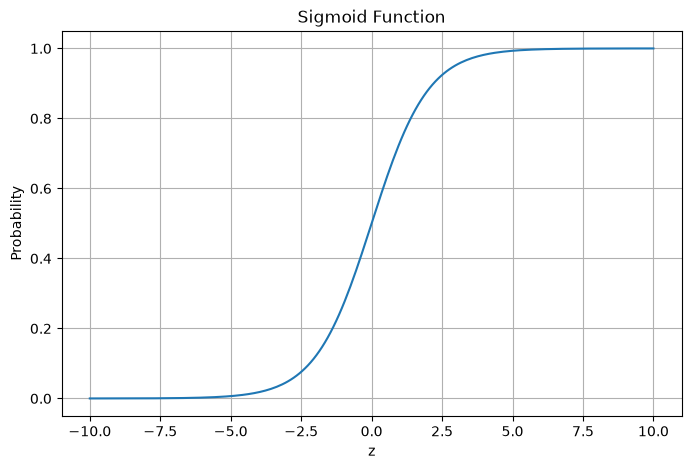

In [14]:
z = np.linspace(-10,10,200)

probability = sigmoid(z)

plt.figure(figsize=(8,5))

plt.plot(z,probability)

plt.title("Sigmoid Function")

plt.xlabel("z")

plt.ylabel("Probability")

plt.grid()

plt.show()

In [15]:
values = [-10,-5,-2,0,2,5,10]

for v in values:

    print(v,"---->",sigmoid(v))

-10 ----> 4.5397868702434395e-05
-5 ----> 0.0066928509242848554
-2 ----> 0.11920292202211755
0 ----> 0.5
2 ----> 0.8807970779778823
5 ----> 0.9933071490757153
10 ----> 0.9999546021312976


In [16]:
x = np.array([2,4])

w = np.array([1.5,-0.8])

b = 0.5

z = np.dot(x,w)+b

print("Weighted Sum =",z)

Weighted Sum = 0.2999999999999998


In [17]:
prob = sigmoid(z)

print("Probability =",prob)

Probability = 0.5744425168116589


In [18]:
if prob >= 0.5:

    print("Class = 1")

else:

    print("Class = 0")

Class = 1


In [19]:
model = LogisticRegression()

model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [20]:
y_pred = model.predict(X_test)

In [21]:
prob = model.predict_proba(X_test)

prob[:10]

array([[1.06463457e-01, 8.93536543e-01],
       [8.98686761e-02, 9.10131324e-01],
       [9.95237675e-01, 4.76232508e-03],
       [1.60434278e-02, 9.83956572e-01],
       [9.99422014e-01, 5.77985907e-04],
       [5.27475821e-01, 4.72524179e-01],
       [9.58888535e-01, 4.11114651e-02],
       [1.59586084e-01, 8.40413916e-01],
       [6.60928341e-01, 3.39071659e-01],
       [3.07273027e-02, 9.69272697e-01]])

In [22]:
comparison = pd.DataFrame({

    "Actual":y_test,

    "Predicted":y_pred

})

comparison.head(15)

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,1,1
4,0,0
5,1,0
6,0,0
7,1,1
8,0,0
9,1,1


In [23]:
accuracy = accuracy_score(

    y_test,

    y_pred

)

print("Accuracy =",accuracy)

Accuracy = 0.96


In [24]:
cm = confusion_matrix(

    y_test,

    y_pred

)

print(cm)

[[50  1]
 [ 3 46]]


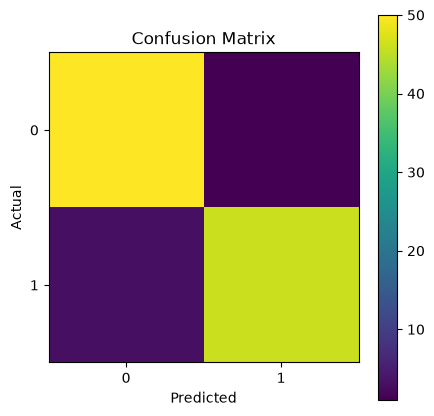

In [25]:
plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks([0,1])

plt.yticks([0,1])

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [26]:
print(classification_report(

    y_test,

    y_pred
))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96        51
           1       0.98      0.94      0.96        49

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100



In [27]:
precision = precision_score(

    y_test,

    y_pred
)

print("Precision =",precision)

Precision = 0.9787234042553191


In [28]:
recall = recall_score(

    y_test,

    y_pred
)

print("Recall =",recall)

Recall = 0.9387755102040817


In [29]:
f1 = f1_score(

    y_test,

    y_pred
)

print("F1 Score =",f1)

F1 Score = 0.9583333333333334
